In [1]:
import numpy as np
import matplotlib.pyplot as plt

import legume
from legume import GuidedModeExp, Circle, Ring, ShapesLayer

%load_ext autoreload
%autoreload 2

## Define W1 waveguide with a supercell

In [226]:
# PhC parameters
a_nm = 250            # lattice constant in nm — change this to rescale the simulation
D = 170 / a_nm          # slab thickness in units of a (always 170 nm physical)
ra = 75 / a_nm           # hole radius in units of a
n_slab = 3.46
eps_b = n_slab**2       # background permittivity
eps_c = 1               # hole permittivity (air)
eps_lower, eps_upper = 1, 1  # cladding permittivities

# supercell parameters
Ny = 12      # Number of rows in the y-direction
Nx = 1       # Supercell size in the x-direction
if (Ny%2 != 0): raise ValueError('number of rows Ny must be even')
Nholes = Nx*(Ny-1)    # total number of holes

# Initialize a rectangular lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

In [227]:
def build_w1_waveguide():
    """Build the standard W1 photonic crystal waveguide supercell.
    The structure is symmetric wrt a xz mirror plane,
    which allows disentangling modes with different kz-symmetry.
    """
    phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)
    phc.add_layer(d=D, eps_b=eps_b)

    xc = []; yc = []; rc = []
    jhole = 0

    for ih in range(1, Ny//2+1):
        for ix in range(-Nx//2+1, Nx//2+1):
            xc.append((ih%2)*0.5 + ix)
            yc.append( ih*np.sqrt(3)/2)
            rc.append(ra)
            jhole += 1
            # upper edge row is half-holes; skip the lower symmetric copy to avoid double counting
            if ih != Ny//2:
                xc.append((ih%2)*0.5 + ix)
                yc.append(-ih*np.sqrt(3)/2)
                rc.append(ra)
                jhole += 1

    for n in range(jhole):
        phc.layers[-1].add_shape(legume.Circle(eps=eps_c, r=rc[n], x_cent=xc[n], y_cent=yc[n]))

    return phc, jhole

Nholes, Nholes_check = 11 11
npw = 255


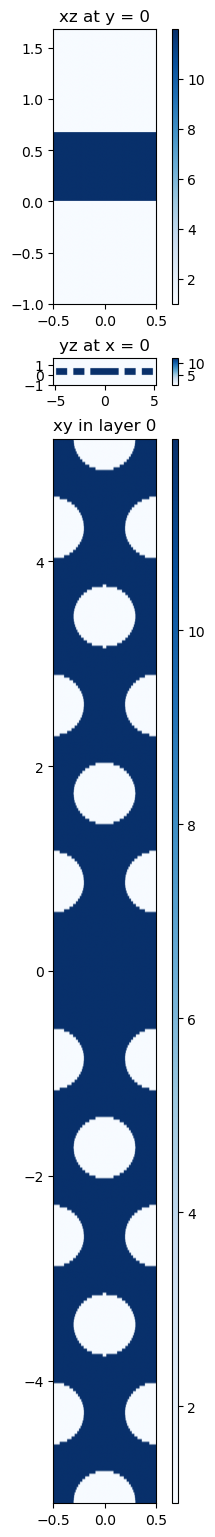

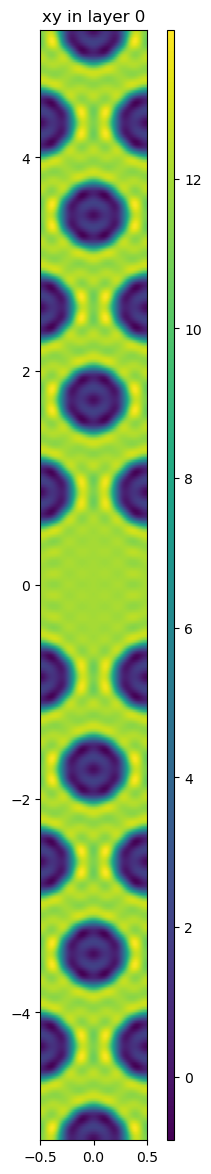

In [228]:
# Initialize the photonic crystal
phc0, Nholes_check = build_w1_waveguide()
print('Nholes, Nholes_check =', Nholes, Nholes_check)

# Visualize the structure
legume.viz.structure(phc0, xz=True, yz=True, figsize=2, cmap='Blues', Nx=400, Ny=400, Nz=200)

gmax = 2.5
truncate_g = 'tbt'
gme0 = legume.GuidedModeExp(phc0, gmax=gmax, truncate_g=truncate_g)
npw = np.shape(gme0.gvec)[1]
print('npw =', npw)

legume.viz.eps_ft(gme0, Nx=400, Ny=400, figsize=2, cbar=True, cmap='viridis')

In [229]:
kz_symmetry = 'odd'

# Define a BZ path in kx and run the GME
# we reduce the number of k-points, to reduce the computing time later
nintervals = 30
nk = nintervals +1
path = lattice.bz_path([[0, 0], np.array([np.pi/Nx, 0])], [nintervals])

kpoints = path['kpoints']
#print(kpoints)

# change of basis for symmetrization can be done with dense or sparse matrices
# in this example with a low number of plane waves they are almost equivalent
# sparse matrices have a more favourable scaling with the number of plane waves
# symmetrization + sparse matrices + autograd is the newest feature of the code, still in beta-testing
use_sparse = True

# we consider only xy-even (TE-like) modes: this is the only polarization yielding a photonic band gap
gmode_inds, numeig = [0], 50

gme0 = legume.GuidedModeExp(phc0, gmax=gmax, truncate_g=truncate_g)
gme0.run(kpoints=path['kpoints'],
        gmode_inds=gmode_inds,
        numeig=numeig,
        verbose=True,
        compute_im=False,
        eig_sigma = 0.0,
        use_sparse=use_sparse,
        kz_symmetry=kz_symmetry, angles=path['angles']
        )

freqs = gme0.freqs
nfreq = np.shape(freqs)[1]
print(freqs.shape)


3.302s total time for real part of frequencies in GuidedModeExp, of which
  1.864s (56%) for guided modes computation using the gmode_compute='exact' method
  0.040s (1%) for inverse matrix of Fourier-space permittivity
  0.351s (11%) for matrix diagionalization using the 'eigh' solver
  0.745s (23%) for creating GME matrix
  0.269s (8%) for creating change of basis matrix and multiply it using sparse matrices
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes
(31, 50)


(0.2, 0.4)

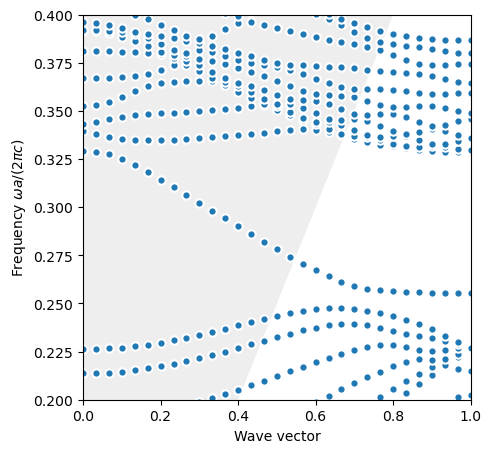

In [230]:
fig, ax = plt.subplots(figsize=(5, 5))
legume.viz.bands(gme0, ax=ax, k_units=True, Q=False)
ax.set_ylim([0.2, 0.4])

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_12149/1569531143.py:6: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('$a k_x/ \pi$')


Text(0, 0.5, 'Frequency')

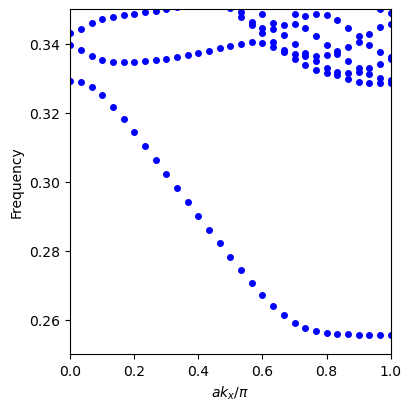

In [231]:
# Plot the (folded) waveguide bands
fig, ax = plt.subplots(1, constrained_layout=True, figsize=(4, 4))
ax.plot(kpoints[0, :]/np.pi, freqs, 'bo', markersize=4)
ax.set_ylim([0.25, 0.35])
ax.set_xlim([0, kpoints[0, -1]/np.pi])
ax.set_xlabel('$a k_x/ \pi$')
ax.set_ylabel('Frequency')

In [232]:
# ---- Select waveguide band (inspect plot above) ----
b_target = 7       # Index of the waveguide defect band

# ---- Extract waveguide band ----
kx = path['kpoints'][0, :]
wg_band = freqs[:, b_target]

# ---- Waveguide band metrics ----
wg_freq_min, wg_freq_max = wg_band.min(), wg_band.max()
wg_bandwidth = wg_freq_max - wg_freq_min
wg_center = (wg_freq_max + wg_freq_min) / 2

# ---- Band edge wavelength ----
f_edge = wg_band[-1]                        # normalized freq at BZ edge
lambda_edge_nm = a_nm / f_edge              # band edge wavelength in nm
lambda_edge_um = lambda_edge_nm / 1000      # band edge wavelength in µm

# ---- Group velocity: v_g = dω/dk (finite differences) ----
dk = np.diff(kx)
domega = np.diff(wg_band)
vg = domega / dk
kx_vg = (kx[:-1] + kx[1:]) / 2
ng = 1.0 / np.abs(vg)

# ---- Print summary ----
print("=" * 50)
print("BAND STRUCTURE METRICS")
print("=" * 50)
print(f"\nWaveguide Band (index {b_target}):")
print(f"  Freq min:          {wg_freq_min:.4f}")
print(f"  Freq max:          {wg_freq_max:.4f}")
print(f"  Bandwidth:         {wg_bandwidth:.4f}")
print(f"  Center frequency:  {wg_center:.4f}")
print(f"\nBand Edge:")
print(f"  f_edge (norm):     {f_edge:.4f}")
print(f"  lambda_edge:       {lambda_edge_nm:.1f} nm  ({lambda_edge_um:.4f} µm)")
print(f"\nGroup Velocity / Index:")
print(f"  v_g range:         [{vg.min():.4f}, {vg.max():.4f}]")
print(f"  n_g range:         [{ng.min():.2f}, {ng.max():.2f}]")
print(f"  n_g at zone edge:  {ng[-1]:.2f}")
print("=" * 50)

BAND STRUCTURE METRICS

Waveguide Band (index 7):
  Freq min:          0.2555
  Freq max:          0.3293
  Bandwidth:         0.0737
  Center frequency:  0.2924

Band Edge:
  f_edge (norm):     0.2555
  lambda_edge:       978.3 nm  (0.9783 µm)

Group Velocity / Index:
  v_g range:         [-0.0388, -0.0001]
  n_g range:         [25.79, 14043.31]
  n_g at zone edge:  14043.31


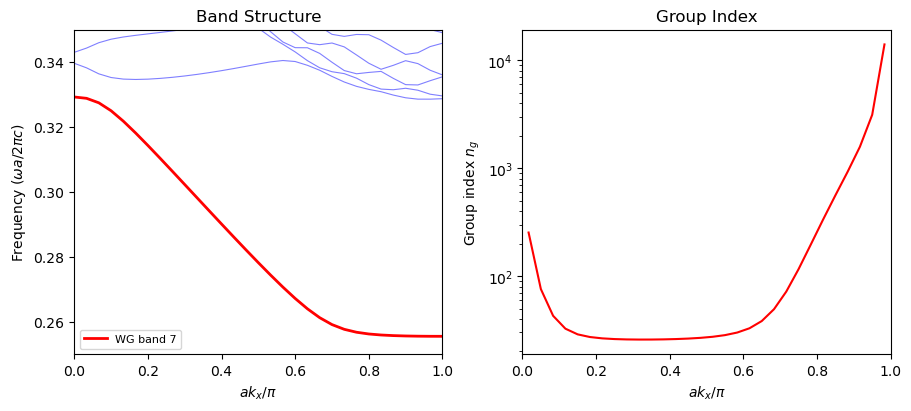

In [233]:
# ---- Band structure + group index plot ----
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(9, 4))

kx_norm = kx / np.pi
ax1.plot(kx_norm, freqs, 'b-', linewidth=0.8, alpha=0.5)
ax1.plot(kx_norm, wg_band, 'r-', linewidth=2, label=f'WG band {b_target}')
ax1.set_ylim([0.25, 0.35])
ax1.set_xlim([0, kx_norm[-1]])
ax1.set_xlabel(r'$a k_x / \pi$')
ax1.set_ylabel(r'Frequency ($\omega a / 2\pi c$)')
ax1.set_title('Band Structure')
ax1.legend(fontsize=8)

ax2.plot(kx_vg / np.pi, ng, 'r-', linewidth=1.5)
ax2.set_xlabel(r'$a k_x / \pi$')
ax2.set_ylabel(r'Group index $n_g$')
ax2.set_xlim([0, kx_norm[-1]])
ax2.set_title('Group Index')
ax2.set_yscale('log')

plt.show()

## Oxidized-hole W1 waveguide
Each air hole gets a thin oxide layer on its inner wall.  
Structure (radially outward): **air core** → **oxide ring** → **silicon**

eps_ft for t_ox = 10.0 nm (oxide rings should be visible)


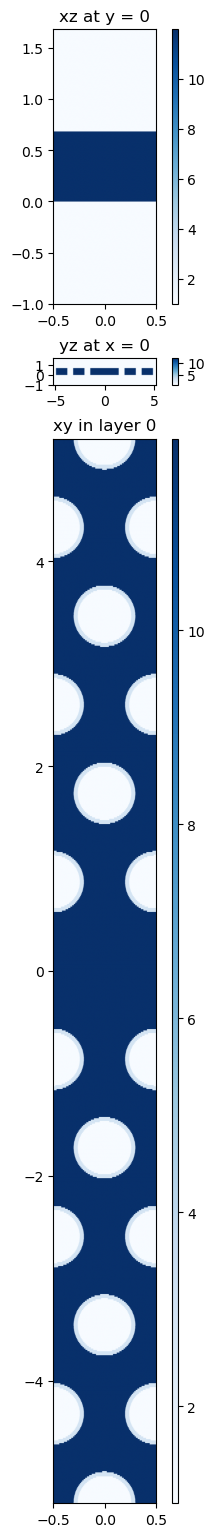

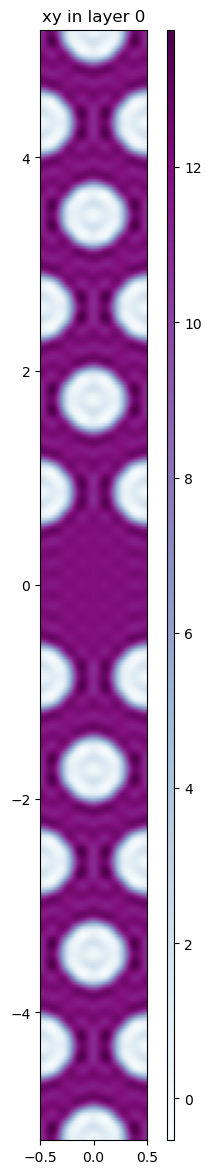

In [235]:
# Oxide parameters
n_oxide = 1.72
eps_oxide = n_oxide**2                         # Oxide permittivity                         
t_ox_values = np.linspace(0.5, 10, 20)          # oxide thicknesses to sweep (in nm)

def build_w1_waveguide_oxidized(t_ox_nm):
    """Build a W1 waveguide where each hole has a thin oxide shell.
    
    Parameters
    ----------
    t_ox_nm : float
        Oxide shell thickness in nm (converted internally to units of a).
    
    Each hole is modeled as:
      - Ring(eps=eps_oxide, r_i=ra-t_ox, r_o=ra)  → oxide shell
      - Circle(eps=eps_c, r=ra-t_ox)               → air core
    These don't overlap, so legume's additive FT gives correct permittivity.
    """
    t_ox = t_ox_nm / a_nm                      # convert nm → units of a
    
    phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)
    phc.add_layer(d=D, eps_b=eps_b)

    r_air = ra - t_ox

    xc = []; yc = []
    jhole = 0

    for ih in range(1, Ny//2+1):
        for ix in range(-Nx//2+1, Nx//2+1):
            xc.append((ih%2)*0.5 + ix)
            yc.append( ih*np.sqrt(3)/2)
            jhole += 1
            if ih != Ny//2:
                xc.append((ih%2)*0.5 + ix)
                yc.append(-ih*np.sqrt(3)/2)
                jhole += 1

    for n in range(jhole):
        phc.layers[-1].add_shape(Ring(eps=eps_oxide, r_i=r_air, r_o=ra,
                                      x_cent=xc[n], y_cent=yc[n]))
        phc.layers[-1].add_shape(Circle(eps=eps_c, r=r_air,
                                        x_cent=xc[n], y_cent=yc[n]))

    return phc, jhole

# Sanity-check visualization for the largest thickness
phc_check, _ = build_w1_waveguide_oxidized(t_ox_values[-1])
gme_check = legume.GuidedModeExp(phc_check, gmax=gmax, truncate_g=truncate_g)
print(f"eps_ft for t_ox = {t_ox_values[-1]:.1f} nm (oxide rings should be visible)")
# Visualize the structure
legume.viz.structure(phc_check, xz=True, yz=True, figsize=2, cmap='Blues', Nx=800, Ny=800, Nz=400)
legume.viz.eps_ft(gme_check, Nx=400, Ny=400, figsize=2, cbar=True, cmap='BuPu')

In [240]:
# ---- Sweep over oxide thicknesses ----
b_target_ox = b_target   # waveguide band index (adjust if needed)

results_ox = []

for t_ox_nm in t_ox_values:
    print(f"\n--- t_ox = {t_ox_nm:.1f} nm ---")
    phc_ox, _ = build_w1_waveguide_oxidized(t_ox_nm)
    gme_ox = legume.GuidedModeExp(phc_ox, gmax=gmax, truncate_g=truncate_g)
    gme_ox.run(kpoints=path['kpoints'],
               gmode_inds=gmode_inds,
               numeig=numeig,
               verbose=False,
               compute_im=False,
               eig_sigma=0.0,
               use_sparse=use_sparse,
               kz_symmetry=kz_symmetry, angles=path['angles'])

    freqs_ox   = gme_ox.freqs
    kx_ox      = path['kpoints'][0, :]
    wg_band_ox = freqs_ox[:, b_target_ox]
    vg_ox      = np.diff(wg_band_ox) / np.diff(kx_ox)
    kx_vg_ox   = (kx_ox[:-1] + kx_ox[1:]) / 2
    ng_ox      = 1.0 / np.abs(vg_ox)

    f_min, f_max = wg_band_ox.min(), wg_band_ox.max()
    f_edge_ox = wg_band_ox[-1]
    lam_edge_nm = a_nm / f_edge_ox
    lam_edge_um = lam_edge_nm / 1000

    print(f"  WG freq:   [{f_min:.4f}, {f_max:.4f}]   bw = {f_max-f_min:.4f}")
    print(f"  Band edge: {lam_edge_um:.4f} µm ({lam_edge_nm:.1f} nm)")
    print(f"  n_g range: [{ng_ox.min():.2f}, {ng_ox.max():.2f}]")

    results_ox.append({
        't_ox_nm': t_ox_nm,
        'freqs':   freqs_ox,
        'wg_band': wg_band_ox,
        'kx_vg':   kx_vg_ox,
        'ng':      ng_ox,
        'f_min':   f_min,
        'f_max':   f_max,
        'f_edge':  f_edge_ox,
        'lam_edge_nm': lam_edge_nm,
        'lam_edge_um': lam_edge_um,
        'bw':      f_max - f_min,
        'center':  (f_min + f_max) / 2,
        'ng_min':  ng_ox.min(),
        'ng_max':  ng_ox.max(),
        'ng_edge': ng_ox[-1],
    })

print("\nSweep complete.")


--- t_ox = 0.5 nm ---
  WG freq:   [0.2555, 0.3291]   bw = 0.0736
  Band edge: 0.9786 µm (978.6 nm)
  n_g range: [25.79, 13690.35]

--- t_ox = 1.0 nm ---
  WG freq:   [0.2554, 0.3289]   bw = 0.0735
  Band edge: 0.9789 µm (978.9 nm)
  n_g range: [25.79, 13349.23]

--- t_ox = 1.5 nm ---
  WG freq:   [0.2553, 0.3287]   bw = 0.0734
  Band edge: 0.9792 µm (979.2 nm)
  n_g range: [25.79, 13019.37]

--- t_ox = 2.0 nm ---
  WG freq:   [0.2552, 0.3285]   bw = 0.0733
  Band edge: 0.9795 µm (979.5 nm)
  n_g range: [25.79, 12700.27]

--- t_ox = 2.5 nm ---
  WG freq:   [0.2552, 0.3283]   bw = 0.0731
  Band edge: 0.9797 µm (979.7 nm)
  n_g range: [25.79, 12391.42]

--- t_ox = 3.0 nm ---
  WG freq:   [0.2551, 0.3281]   bw = 0.0730
  Band edge: 0.9800 µm (980.0 nm)
  n_g range: [25.79, 12092.39]

--- t_ox = 3.5 nm ---
  WG freq:   [0.2550, 0.3279]   bw = 0.0729
  Band edge: 0.9803 µm (980.3 nm)
  n_g range: [25.78, 11802.75]

--- t_ox = 4.0 nm ---
  WG freq:   [0.2549, 0.3277]   bw = 0.0727
  Band ed

## Comparison: Original vs Oxidized

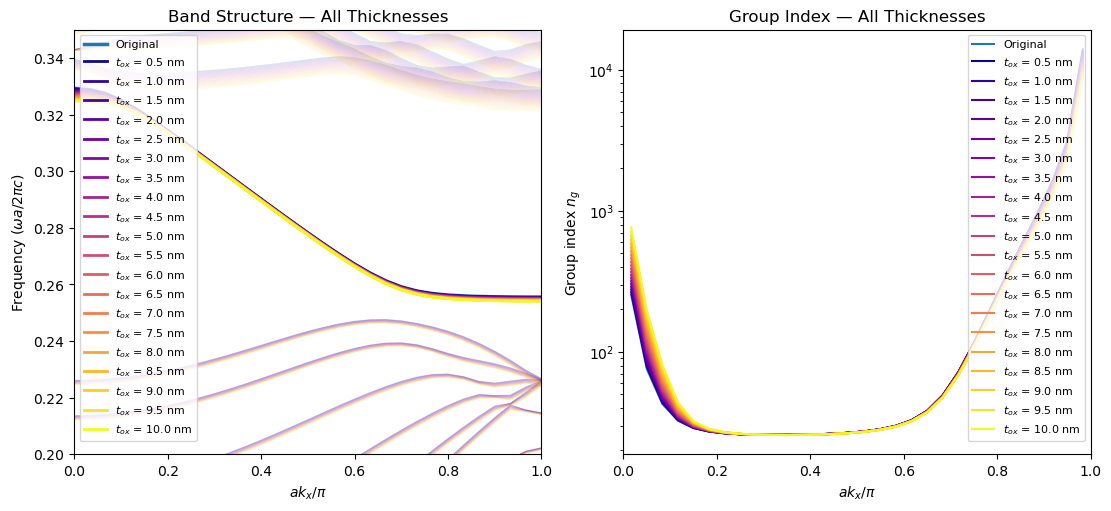

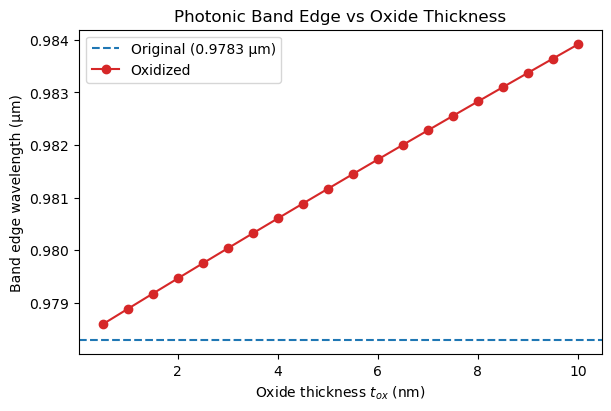

COMPARISON TABLE
 t_ox (nm)    f_edge      λ_edge     f_min     f_max        bw    ng_min   ng_edge
------------------------------------------------------------------------------------------
  original    0.2555     0.9783µm    0.2555    0.3293    0.0737     25.79  14043.31
       0.5    0.2555     0.9786µm    0.2555    0.3291    0.0736     25.79  13690.35
       1.0    0.2554     0.9789µm    0.2554    0.3289    0.0735     25.79  13349.23
       1.5    0.2553     0.9792µm    0.2553    0.3287    0.0734     25.79  13019.37
       2.0    0.2552     0.9795µm    0.2552    0.3285    0.0733     25.79  12700.27
       2.5    0.2552     0.9797µm    0.2552    0.3283    0.0731     25.79  12391.42
       3.0    0.2551     0.9800µm    0.2551    0.3281    0.0730     25.79  12092.39
       3.5    0.2550     0.9803µm    0.2550    0.3279    0.0729     25.78  11802.75
       4.0    0.2549     0.9806µm    0.2549    0.3277    0.0727     25.78  11522.10
       4.5    0.2549     0.9809µm    0.2549    0.3274

In [242]:
# ---- Overlay: original + all oxidized thicknesses ----
cmap = plt.cm.plasma
colors = [cmap(i / max(len(results_ox) - 1, 1)) for i in range(len(results_ox))]

kx_norm = kx / np.pi
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(11, 5))

# --- Band structures ---
ax1.plot(kx_norm, freqs, '-', color='tab:blue', linewidth=0.5, alpha=0.2)
ax1.plot(kx_norm, wg_band, '-', color='tab:blue', linewidth=2.5, label='Original')

for r, c in zip(results_ox, colors):
    ax1.plot(kx_norm, r['freqs'], '-', color=c, linewidth=0.5, alpha=0.15)
    ax1.plot(kx_norm, r['wg_band'], '-', color=c, linewidth=2,
             label=f"$t_{{ox}}$ = {r['t_ox_nm']:.1f} nm")

ax1.set_ylim([0.2, 0.35])
ax1.set_xlim([0, kx_norm[-1]])
ax1.set_xlabel(r'$a k_x / \pi$')
ax1.set_ylabel(r'Frequency ($\omega a / 2\pi c$)')
ax1.set_title('Band Structure — All Thicknesses')
ax1.legend(fontsize=8, loc='upper left')

# --- Group index ---
ax2.plot(kx_vg / np.pi, ng, '-', color='tab:blue', linewidth=1.5, label='Original')
for r, c in zip(results_ox, colors):
    ax2.plot(r['kx_vg'] / np.pi, r['ng'], '-', color=c, linewidth=1.5,
             label=f"$t_{{ox}}$ = {r['t_ox_nm']:.1f} nm")

ax2.set_xlabel(r'$a k_x / \pi$')
ax2.set_ylabel(r'Group index $n_g$')
ax2.set_xlim([0, kx_norm[-1]])
ax2.set_title('Group Index — All Thicknesses')
ax2.set_yscale('log')
ax2.legend(fontsize=8)

plt.show()

# ---- Band edge wavelength vs oxide thickness plot ----
fig2, ax3 = plt.subplots(1, 1, constrained_layout=True, figsize=(6, 4))
t_ox_arr = [r['t_ox_nm'] for r in results_ox]
lam_arr  = [r['lam_edge_um'] for r in results_ox]
ax3.axhline(lambda_edge_um, color='tab:blue', linestyle='--', label=f'Original ({lambda_edge_um:.4f} µm)')
ax3.plot(t_ox_arr, lam_arr, 'o-', color='tab:red', markersize=6, label='Oxidized')
ax3.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax3.set_ylabel(r'Band edge wavelength (µm)')
ax3.set_title('Photonic Band Edge vs Oxide Thickness')
ax3.legend()
plt.show()

# ---- Metrics table ----
print("=" * 90)
print("COMPARISON TABLE")
print("=" * 90)
print(f"{'t_ox (nm)':>10}  {'f_edge':>8}  {'λ_edge':>10}  {'f_min':>8}  {'f_max':>8}  {'bw':>8}  {'ng_min':>8}  {'ng_edge':>8}")
print("-" * 90)
print(f"{'original':>10}  {f_edge:>8.4f}  {lambda_edge_um:>9.4f}µm  {wg_freq_min:>8.4f}  {wg_freq_max:>8.4f}  {wg_bandwidth:>8.4f}  {ng.min():>8.2f}  {ng[-1]:>8.2f}")
for r in results_ox:
    print(f"{r['t_ox_nm']:>10.1f}  {r['f_edge']:>8.4f}  {r['lam_edge_um']:>9.4f}µm  {r['f_min']:>8.4f}  {r['f_max']:>8.4f}  {r['bw']:>8.4f}  {r['ng_min']:>8.2f}  {r['ng_edge']:>8.2f}")
print("=" * 90)

## Band Edge Heatmap: Hole Radius vs Lattice Constant

In [243]:
# ---- Self-contained band edge computation ----
def compute_band_edge(a_nm_val, r_nm_val, t_ox=0):
    """Compute band edge wavelength (µm) for given physical parameters."""
    D_val  = 170 / a_nm_val
    ra_val = r_nm_val / a_nm_val

    phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)
    phc.add_layer(d=D_val, eps_b=eps_b)

    for ih in range(1, Ny//2+1):
        for ix in range(-Nx//2+1, Nx//2+1):
            xc = (ih%2)*0.5 + ix
            yc_pos = ih*np.sqrt(3)/2
            positions = [(xc, yc_pos), (xc, -yc_pos)] if ih != Ny//2 else [(xc, yc_pos)]
            for (x, y) in positions:
                if t_ox > 0:
                    r_air = ra_val - t_ox
                    phc.layers[-1].add_shape(Ring(eps=eps_oxide, r_i=r_air, r_o=ra_val, x_cent=x, y_cent=y))
                    phc.layers[-1].add_shape(Circle(eps=eps_c, r=r_air, x_cent=x, y_cent=y))
                else:
                    phc.layers[-1].add_shape(Circle(eps=eps_c, r=ra_val, x_cent=x, y_cent=y))

    gme = legume.GuidedModeExp(phc, gmax=gmax, truncate_g=truncate_g)
    gme.run(kpoints=path['kpoints'], gmode_inds=gmode_inds, numeig=numeig,
            verbose=False, compute_im=False, eig_sigma=0.0,
            use_sparse=use_sparse, kz_symmetry=kz_symmetry, angles=path['angles'])

    f_edge = gme.freqs[-1, b_target]
    return a_nm_val / f_edge / 1000  # λ_edge in µm

In [244]:

# ---- Sweep parameters ----
r_nm_values = np.linspace(70, 84, 5)        # hole radius in nm
a_nm_values = np.arange(246, 254, 2)      # lattice constant in nm
t_ox_nm_sweep  = [0, 1, 3, 5]             # oxide thicknesses in nm
t_ox_nm_labels = ['No oxide',
                  r'$t_{ox}=1\,$nm',
                  r'$t_{ox}=3\,$nm',
                  r'$t_{ox}=5\,$nm']

n_total = len(t_ox_nm_sweep) * len(a_nm_values) * len(r_nm_values)
heatmap_data = {}

count = 0
for t_ox_nm in t_ox_nm_sweep:
    data = np.zeros((len(a_nm_values), len(r_nm_values)))
    for ia, a_val in enumerate(a_nm_values):
        for ir, r_val in enumerate(r_nm_values):
            count += 1
            t_ox_norm = t_ox_nm / a_val      # nm → units of a
            lam = compute_band_edge(a_val, r_val, t_ox=t_ox_norm)
            data[ia, ir] = lam
            print(f"[{count}/{n_total}] t_ox={t_ox_nm}nm, a={a_val}nm, r={r_val}nm → λ_edge={lam:.4f} µm")
    heatmap_data[t_ox_nm] = data

print("\nHeatmap sweep complete.")

[1/80] t_ox=0nm, a=246nm, r=70.0nm → λ_edge=0.9780 µm
[2/80] t_ox=0nm, a=246nm, r=73.5nm → λ_edge=0.9667 µm
[3/80] t_ox=0nm, a=246nm, r=77.0nm → λ_edge=0.9548 µm
[4/80] t_ox=0nm, a=246nm, r=80.5nm → λ_edge=0.9423 µm
[5/80] t_ox=0nm, a=246nm, r=84.0nm → λ_edge=0.9288 µm
[6/80] t_ox=0nm, a=248nm, r=70.0nm → λ_edge=0.9862 µm
[7/80] t_ox=0nm, a=248nm, r=73.5nm → λ_edge=0.9749 µm
[8/80] t_ox=0nm, a=248nm, r=77.0nm → λ_edge=0.9632 µm
[9/80] t_ox=0nm, a=248nm, r=80.5nm → λ_edge=0.9509 µm
[10/80] t_ox=0nm, a=248nm, r=84.0nm → λ_edge=0.9376 µm
[11/80] t_ox=0nm, a=250nm, r=70.0nm → λ_edge=0.9943 µm
[12/80] t_ox=0nm, a=250nm, r=73.5nm → λ_edge=0.9832 µm
[13/80] t_ox=0nm, a=250nm, r=77.0nm → λ_edge=0.9716 µm
[14/80] t_ox=0nm, a=250nm, r=80.5nm → λ_edge=0.9594 µm
[15/80] t_ox=0nm, a=250nm, r=84.0nm → λ_edge=0.9464 µm
[16/80] t_ox=0nm, a=252nm, r=70.0nm → λ_edge=1.0024 µm
[17/80] t_ox=0nm, a=252nm, r=73.5nm → λ_edge=0.9914 µm
[18/80] t_ox=0nm, a=252nm, r=77.0nm → λ_edge=0.9799 µm
[19/80] t_ox=0nm, a

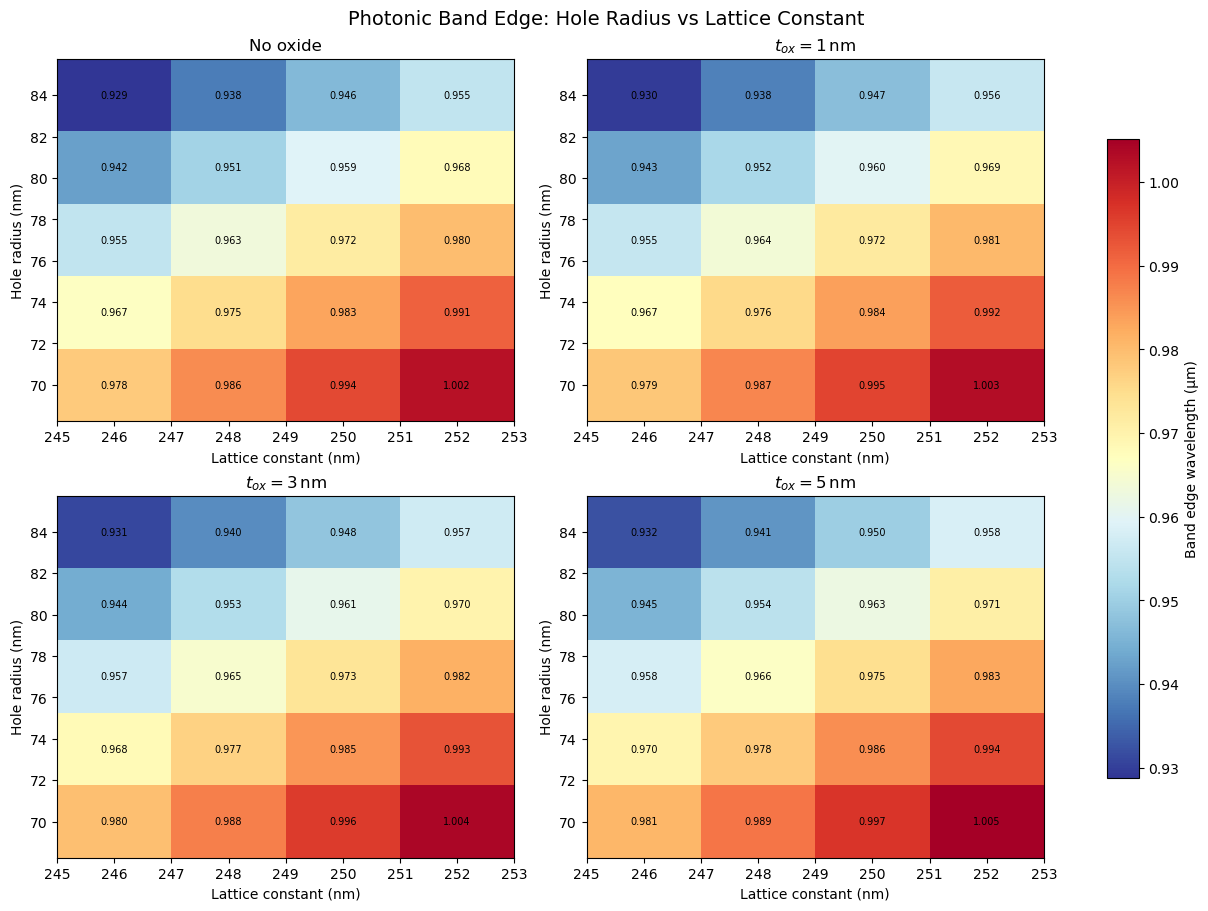

In [245]:
# ---- Band edge heatmaps ----
# Shared color range across all subplots
all_vals = np.concatenate([heatmap_data[t].ravel() for t in t_ox_nm_sweep])
vmin, vmax = all_vals.min(), all_vals.max()

fig, axes = plt.subplots(2, 2, constrained_layout=True, figsize=(12, 9))

for ax, t_ox_nm, label in zip(axes.ravel(), t_ox_nm_sweep, t_ox_nm_labels):
    im = ax.pcolormesh(a_nm_values, r_nm_values, heatmap_data[t_ox_nm].T,
                       cmap='RdYlBu_r', vmin=vmin, vmax=vmax, shading='nearest')
    ax.set_xlabel('Lattice constant (nm)')
    ax.set_ylabel('Hole radius (nm)')
    ax.set_title(label)
    # Annotate each cell with the value
    for ia in range(len(a_nm_values)):
        for ir in range(len(r_nm_values)):
            ax.text(a_nm_values[ia], r_nm_values[ir],
                    f'{heatmap_data[t_ox_nm][ia, ir]:.3f}',
                    ha='center', va='center', fontsize=7, color='k')

fig.colorbar(im, ax=axes, label=r'Band edge wavelength (µm)', shrink=0.8)
fig.suptitle('Photonic Band Edge: Hole Radius vs Lattice Constant', fontsize=14)
plt.show()

## Band Edge Heatmap: Constant Physical Oxide Thickness
In the previous heatmap, `t_ox` is in units of `a`, so the **physical** oxide  
thickness varies with lattice constant. Here we fix the oxide thickness in  
absolute **nm** so it stays constant across the entire `a` sweep.

In [ ]:
# ---- Band edge heatmap: CONSTANT physical oxide thickness (nm) ----
# t_ox in nm → normalized per a-value as t_ox_norm = t_ox_nm / a_nm
t_ox_nm_sweep  = [0, 1, 3, 5]            # physical oxide thickness in nm
t_ox_nm_labels = ['No oxide',
                  r'$t_{ox}=1\,$nm',
                  r'$t_{ox}=3\,$nm',
                  r'$t_{ox}=5\,$nm']

n_total_abs = len(t_ox_nm_sweep) * len(a_nm_values) * len(r_nm_values)
heatmap_data_abs = {}

count = 0
for t_ox_nm in t_ox_nm_sweep:
    data = np.zeros((len(a_nm_values), len(r_nm_values)))
    for ia, a_val in enumerate(a_nm_values):
        for ir, r_val in enumerate(r_nm_values):
            count += 1
            t_ox_norm = t_ox_nm / a_val          # nm → units of a
            lam = compute_band_edge(a_val, r_val, t_ox=t_ox_norm)
            data[ia, ir] = lam
            print(f"[{count}/{n_total_abs}] t_ox={t_ox_nm}nm (={t_ox_norm:.4f}a), "
                  f"a={a_val}nm, r={r_val}nm → λ_edge={lam:.4f} µm")
    heatmap_data_abs[t_ox_nm] = data

print("\nHeatmap sweep (constant physical oxide) complete.")

# ---- Plot ----
all_vals_abs = np.concatenate([heatmap_data_abs[t].ravel() for t in t_ox_nm_sweep])
vmin_abs, vmax_abs = all_vals_abs.min(), all_vals_abs.max()

fig, axes = plt.subplots(2, 2, constrained_layout=True, figsize=(12, 9))

for ax, t_ox_nm, label in zip(axes.ravel(), t_ox_nm_sweep, t_ox_nm_labels):
    im = ax.pcolormesh(a_nm_values, r_nm_values, heatmap_data_abs[t_ox_nm].T,
                       cmap='RdYlBu_r', vmin=vmin_abs, vmax=vmax_abs, shading='nearest')
    ax.set_xlabel('Lattice constant (nm)')
    ax.set_ylabel('Hole radius (nm)')
    ax.set_title(label)
    for ia in range(len(a_nm_values)):
        for ir in range(len(r_nm_values)):
            ax.text(a_nm_values[ia], r_nm_values[ir],
                    f'{heatmap_data_abs[t_ox_nm][ia, ir]:.3f}',
                    ha='center', va='center', fontsize=7, color='k')

fig.colorbar(im, ax=axes, label=r'Band edge wavelength (µm)', shrink=0.8)
fig.suptitle('Photonic Band Edge (Constant Physical Oxide Thickness)', fontsize=14)
plt.show()

## Band Edge vs Oxide Thickness: Parameter Sweeps
Each plot shows band edge wavelength as a function of oxide thickness,  
with multiple curves for different structural parameters.

[1/40] r=70.0nm, t_ox=0.0nm → λ_edge=0.9943 µm
[2/40] r=70.0nm, t_ox=0.2nm → λ_edge=0.9944 µm
[3/40] r=70.0nm, t_ox=0.4nm → λ_edge=0.9946 µm
[4/40] r=70.0nm, t_ox=0.7nm → λ_edge=0.9947 µm
[5/40] r=70.0nm, t_ox=0.9nm → λ_edge=0.9948 µm
[6/40] r=70.0nm, t_ox=1.1nm → λ_edge=0.9949 µm
[7/40] r=70.0nm, t_ox=1.3nm → λ_edge=0.9951 µm
[8/40] r=70.0nm, t_ox=1.6nm → λ_edge=0.9952 µm
[9/40] r=70.0nm, t_ox=1.8nm → λ_edge=0.9953 µm
[10/40] r=70.0nm, t_ox=2.0nm → λ_edge=0.9954 µm
[11/40] r=74.0nm, t_ox=0.0nm → λ_edge=0.9816 µm
[12/40] r=74.0nm, t_ox=0.2nm → λ_edge=0.9817 µm
[13/40] r=74.0nm, t_ox=0.4nm → λ_edge=0.9818 µm
[14/40] r=74.0nm, t_ox=0.7nm → λ_edge=0.9820 µm
[15/40] r=74.0nm, t_ox=0.9nm → λ_edge=0.9821 µm
[16/40] r=74.0nm, t_ox=1.1nm → λ_edge=0.9822 µm
[17/40] r=74.0nm, t_ox=1.3nm → λ_edge=0.9823 µm
[18/40] r=74.0nm, t_ox=1.6nm → λ_edge=0.9825 µm
[19/40] r=74.0nm, t_ox=1.8nm → λ_edge=0.9826 µm
[20/40] r=74.0nm, t_ox=2.0nm → λ_edge=0.9827 µm
[21/40] r=78.0nm, t_ox=0.0nm → λ_edge=0.9682 µm
[

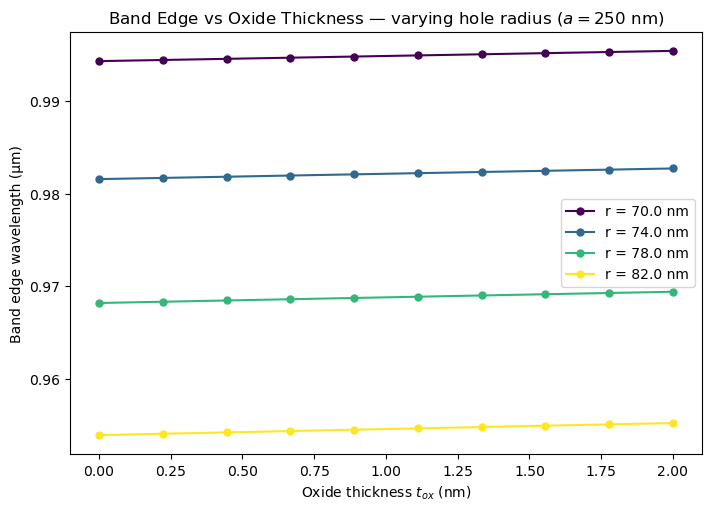

In [249]:
# ---- Band edge vs oxide thickness for different hole radii (fixed a) ----
a_fixed = 250                                 # fixed lattice constant (nm)
r_sweep = np.linspace(70, 82, 4)             # hole radii to compare (nm)
t_ox_sweep_fine = np.linspace(0, 2, 10)      # oxide thickness sweep (nm)

sweep_r_results = {}
n_total = len(r_sweep) * len(t_ox_sweep_fine)
count = 0

for r_val in r_sweep:
    lam_arr = []
    for t_ox_nm in t_ox_sweep_fine:
        count += 1
        t_ox_norm = t_ox_nm / a_fixed
        lam = compute_band_edge(a_fixed, r_val, t_ox=t_ox_norm)
        lam_arr.append(lam)
        print(f"[{count}/{n_total}] r={r_val:.1f}nm, t_ox={t_ox_nm:.1f}nm → λ_edge={lam:.4f} µm")
    sweep_r_results[r_val] = np.array(lam_arr)

print("\nSweep complete.")

# ---- Plot ----
fig, ax = plt.subplots(constrained_layout=True, figsize=(7, 5))
cmap = plt.cm.viridis
colors = [cmap(i / max(len(r_sweep) - 1, 1)) for i in range(len(r_sweep))]

for r_val, c in zip(r_sweep, colors):
    ax.plot(t_ox_sweep_fine, sweep_r_results[r_val], 'o-', color=c,
            markersize=5, linewidth=1.5, label=f'r = {r_val:.1f} nm')

ax.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax.set_ylabel(r'Band edge wavelength (µm)')
ax.set_title(f'Band Edge vs Oxide Thickness — varying hole radius ($a = {a_fixed}$ nm)')
ax.legend()
plt.show()

[1/40] a=246nm, t_ox=0.0nm → λ_edge=0.9617 µm
[2/40] a=246nm, t_ox=0.2nm → λ_edge=0.9618 µm
[3/40] a=246nm, t_ox=0.4nm → λ_edge=0.9619 µm
[4/40] a=246nm, t_ox=0.7nm → λ_edge=0.9621 µm
[5/40] a=246nm, t_ox=0.9nm → λ_edge=0.9622 µm
[6/40] a=246nm, t_ox=1.1nm → λ_edge=0.9623 µm
[7/40] a=246nm, t_ox=1.3nm → λ_edge=0.9625 µm
[8/40] a=246nm, t_ox=1.6nm → λ_edge=0.9626 µm
[9/40] a=246nm, t_ox=1.8nm → λ_edge=0.9627 µm
[10/40] a=246nm, t_ox=2.0nm → λ_edge=0.9628 µm
[11/40] a=248nm, t_ox=0.0nm → λ_edge=0.9700 µm
[12/40] a=248nm, t_ox=0.2nm → λ_edge=0.9701 µm
[13/40] a=248nm, t_ox=0.4nm → λ_edge=0.9703 µm
[14/40] a=248nm, t_ox=0.7nm → λ_edge=0.9704 µm
[15/40] a=248nm, t_ox=0.9nm → λ_edge=0.9705 µm
[16/40] a=248nm, t_ox=1.1nm → λ_edge=0.9707 µm
[17/40] a=248nm, t_ox=1.3nm → λ_edge=0.9708 µm
[18/40] a=248nm, t_ox=1.6nm → λ_edge=0.9709 µm
[19/40] a=248nm, t_ox=1.8nm → λ_edge=0.9710 µm
[20/40] a=248nm, t_ox=2.0nm → λ_edge=0.9712 µm
[21/40] a=250nm, t_ox=0.0nm → λ_edge=0.9783 µm
[22/40] a=250nm, t_ox=

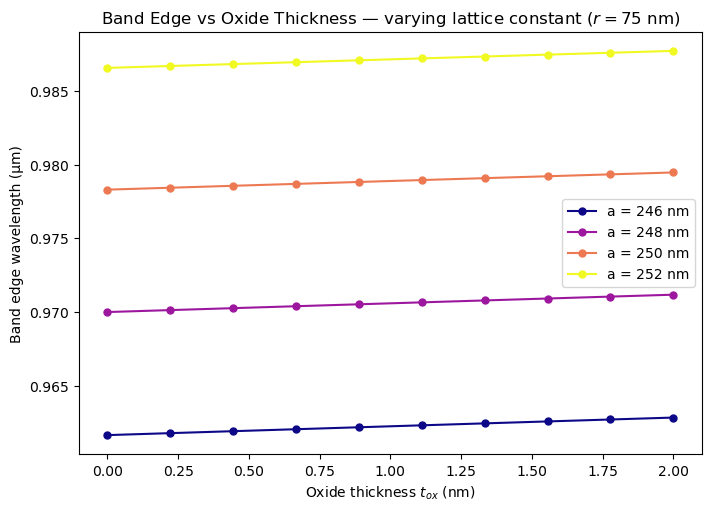

In [251]:
# ---- Band edge vs oxide thickness for different lattice constants (fixed r) ----
r_fixed = 75                                  # fixed hole radius (nm)
a_sweep = np.linspace(246, 252, 4)           # lattice constants to compare (nm)

sweep_a_results = {}
n_total = len(a_sweep) * len(t_ox_sweep_fine)
count = 0

for a_val in a_sweep:
    lam_arr = []
    for t_ox_nm in t_ox_sweep_fine:
        count += 1
        t_ox_norm = t_ox_nm / a_val
        lam = compute_band_edge(a_val, r_fixed, t_ox=t_ox_norm)
        lam_arr.append(lam)
        print(f"[{count}/{n_total}] a={a_val:.0f}nm, t_ox={t_ox_nm:.1f}nm → λ_edge={lam:.4f} µm")
    sweep_a_results[a_val] = np.array(lam_arr)

print("\nSweep complete.")

# ---- Plot ----
fig, ax = plt.subplots(constrained_layout=True, figsize=(7, 5))
cmap = plt.cm.plasma
colors = [cmap(i / max(len(a_sweep) - 1, 1)) for i in range(len(a_sweep))]

for a_val, c in zip(a_sweep, colors):
    ax.plot(t_ox_sweep_fine, sweep_a_results[a_val], 'o-', color=c,
            markersize=5, linewidth=1.5, label=f'a = {a_val:.0f} nm')

ax.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax.set_ylabel(r'Band edge wavelength (µm)')
ax.set_title(f'Band Edge vs Oxide Thickness — varying lattice constant ($r = {r_fixed}$ nm)')
ax.legend()
plt.show()

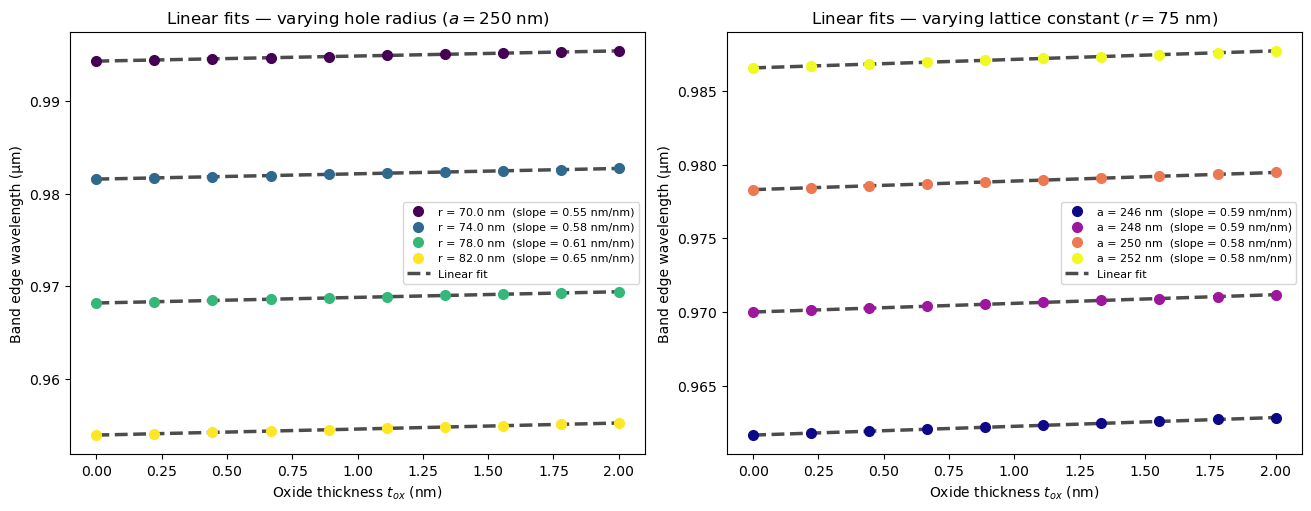

LINEAR FIT SLOPES:  dλ_edge / dt_ox

Varying hole radius (a = 250 nm):
      r (nm)   slope (nm/nm)
  ----------  --------------
        70.0           0.554
        74.0           0.575
        78.0           0.608
        82.0           0.652

Varying lattice constant (r = 75 nm):
      a (nm)   slope (nm/nm)
  ----------  --------------
         246           0.595
         248           0.588
         250           0.582
         252           0.577

Mean slope:  0.591 nm/nm
Std dev:     0.027 nm/nm


In [252]:
# ---- Linear fits: extract dλ/dt_ox slope ----
t_fit = np.linspace(t_ox_sweep_fine[0], t_ox_sweep_fine[-1], 100)

# Fit each curve
fits_r = {}  # {r_val: (slope, intercept)}
for r_val in r_sweep:
    slope, intercept = np.polyfit(t_ox_sweep_fine, sweep_r_results[r_val], 1)
    fits_r[r_val] = (slope, intercept)

fits_a = {}  # {a_val: (slope, intercept)}
for a_val in a_sweep:
    slope, intercept = np.polyfit(t_ox_sweep_fine, sweep_a_results[a_val], 1)
    fits_a[a_val] = (slope, intercept)

# ---- Plot: data + fit lines ----
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(13, 5))

# Left: varying r
cmap1 = plt.cm.viridis
colors1 = [cmap1(i / max(len(r_sweep) - 1, 1)) for i in range(len(r_sweep))]
for r_val, c in zip(r_sweep, colors1):
    slope, intercept = fits_r[r_val]
    ax1.plot(t_ox_sweep_fine, sweep_r_results[r_val], 'o', color=c,
             markersize=7, zorder=3)
    ax1.plot(t_fit, slope * t_fit + intercept, '--', color='k',
             linewidth=2.5, alpha=0.7, zorder=2)
    # invisible line just for the legend entry combining color + slope
    ax1.plot([], [], 'o', color=c, markersize=7,
             label=f'r = {r_val:.1f} nm  (slope = {slope*1e3:.2f} nm/nm)')
ax1.plot([], [], '--', color='k', linewidth=2.5, alpha=0.7, label='Linear fit')
ax1.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax1.set_ylabel(r'Band edge wavelength (µm)')
ax1.set_title(f'Linear fits — varying hole radius ($a = {a_fixed}$ nm)')
ax1.legend(fontsize=8)

# Right: varying a
cmap2 = plt.cm.plasma
colors2 = [cmap2(i / max(len(a_sweep) - 1, 1)) for i in range(len(a_sweep))]
for a_val, c in zip(a_sweep, colors2):
    slope, intercept = fits_a[a_val]
    ax2.plot(t_ox_sweep_fine, sweep_a_results[a_val], 'o', color=c,
             markersize=7, zorder=3)
    ax2.plot(t_fit, slope * t_fit + intercept, '--', color='k',
             linewidth=2.5, alpha=0.7, zorder=2)
    ax2.plot([], [], 'o', color=c, markersize=7,
             label=f'a = {a_val:.0f} nm  (slope = {slope*1e3:.2f} nm/nm)')
ax2.plot([], [], '--', color='k', linewidth=2.5, alpha=0.7, label='Linear fit')
ax2.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax2.set_ylabel(r'Band edge wavelength (µm)')
ax2.set_title(f'Linear fits — varying lattice constant ($r = {r_fixed}$ nm)')
ax2.legend(fontsize=8)

plt.show()

# ---- Summary table ----
print("=" * 60)
print("LINEAR FIT SLOPES:  dλ_edge / dt_ox")
print("=" * 60)
print(f"\nVarying hole radius (a = {a_fixed} nm):")
print(f"  {'r (nm)':>10}  {'slope (nm/nm)':>14}")
print(f"  {'-'*10}  {'-'*14}")
for r_val in r_sweep:
    s = fits_r[r_val][0] * 1e3  # µm/nm → nm/nm
    print(f"  {r_val:>10.1f}  {s:>14.3f}")

print(f"\nVarying lattice constant (r = {r_fixed} nm):")
print(f"  {'a (nm)':>10}  {'slope (nm/nm)':>14}")
print(f"  {'-'*10}  {'-'*14}")
for a_val in a_sweep:
    s = fits_a[a_val][0] * 1e3  # µm/nm → nm/nm
    print(f"  {a_val:>10.0f}  {s:>14.3f}")

# Overall average
all_slopes = [fits_r[r][0]*1e3 for r in r_sweep] + [fits_a[a][0]*1e3 for a in a_sweep]
print(f"\nMean slope:  {np.mean(all_slopes):.3f} nm/nm")
print(f"Std dev:     {np.std(all_slopes):.3f} nm/nm")
print("=" * 60)